In [32]:
import numpy as np
from typing import List, Any
from tqdm import tqdm
from __future__ import annotations
from typing import List, Sequence

import matplotlib.pyplot as plt
Array = np.ndarray


def compress(mpo: List[Any],
             D_max: int,
             svd_eps: float = 1e-30) -> List[Any]:
    
    L  = len(mpo)
    d  = mpo[0].shape[1]
    p  = d * d                   
    C  = [T.copy() for T in mpo] 

    # ------------------------------------------------------------------
    # 2) RIGHT-TO-LEFT  SVD  SWEEP
    # ------------------------------------------------------------------
    for i in range(L - 1, 0, -1):
        Dl, _, _, Dr = C[i].shape
        M = C[i].reshape(Dl, p * Dr)                 # (D_L, p*D_R)

        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        r_s = min(D_max, np.count_nonzero(S > svd_eps))
        r_s = max(r_s, 1) 
        U, S, Vh = U[:, :r_s], S[:r_s], Vh[:r_s, :]
        C[i] = Vh.reshape(r_s, d, d, Dr)
        US = U @ np.diag(S)                          # (D_L, r_s)

        Dl1, _, _, Dr1 = C[i - 1].shape
        assert Dr1 == Dl, f"bond mismatch between sites {i-1} and {i}"

        left = C[i - 1].reshape(Dl1 * p, Dl) @ US    # (D_L1*p, r_s)
        C[i - 1] = left.reshape(Dl1, d, d, r_s)

    for i in range(0, L - 1):
        Dl, _, _, Dr = C[i].shape             # (D_L, d, d, D_R)
        M = C[i].reshape(Dl * p, Dr)          # (D_L*p, D_R)

        Q, R = np.linalg.qr(M, mode='reduced')  # Q: (D_L*p, r_q),  R: (r_q, D_R)
        r_q  = min(D_max, Q.shape[1])
        Q, R = Q[:, :r_q], R[:r_q, :]          
        C[i] = Q.reshape(Dl, d, d, r_q)
        Dl1, _, _, Dr1 = C[i + 1].shape
        assert Dl1 == Dr, f"bond mismatch between sites {i} and {i+1}"

        right = R @ C[i + 1].reshape(Dl1, p * Dr1)   # (r_q, p*D_R1)
        C[i + 1] = right.reshape(r_q, d, d, Dr1)

    

    return C


def product(WA: List[Array], WB: List[Array]) -> List[Array]:
   
    L = len(WA)
    C  = []

    for i in range(L):
        A = WA[i]               
        B = WB[i]                   

        if A.shape[1:3] != B.shape[1:3]:
            raise ValueError(f"Physical dims differ at site {i}")
        d = A.shape[1]

        DₐL, _, _, DₐR = A.shape
        DᵦL, _, _, DᵦR = B.shape

        tmp = np.tensordot(A, B, axes=([2], [1]))

        tmp = tmp.transpose(0, 3, 1, 4, 2, 5)

        C_i = tmp.reshape(DₐL * DᵦL, d, d, DₐR * DᵦR)

        C.append(C_i)

    return C


def trace(Wlist):
    
    Ti = []
    for W in Wlist:
        D_left, d, _, D_right = W.shape
        T  = np.zeros((D_left, D_right), dtype=W.dtype)
        for σ in range(d):
            T += W[:, σ, σ, :]
        Ti.append(T)

    M = Ti[0] 
    for T in Ti[1:]:
        M = M @ T   
    return M.item()


In [33]:
I  = np.eye(2, dtype=complex)
S_plus = np.array([[0, 1], [0, 0]], dtype=complex)
S_minus = np.array([[0, 0], [1, 0]], dtype=complex)
Sx = (S_plus + S_minus) / np.sqrt(2)
Sy = (S_plus - S_minus) / (1j * np.sqrt(2))
zero=np.zeros(2)


def identity_mpo(L: int) -> List[Array]:
    return [I.reshape(1, 2, 2, 1).copy() for _ in range(L)]

def xy_hamiltonian_mpo(L: int, J: float = 1.0) -> List[Array]:
    
    D = 4
    W: List[Array] = [None] * L
    Wl = np.zeros((1, 2, 2, D), dtype=complex)
    Wl[0, :, :, 0] = 0
    Wl[0, :, :, 1] = J*Sx
    Wl[0, :, :, 2] = J*Sy
    Wl[0, :, :, 3] = I
    W[0] = Wl

    Wr = np.zeros((D, 2, 2, 1), dtype=complex)
    Wr[0, :, :, 0] = I
    Wr[1, :, :, 0] = Sx
    Wr[2, :, :, 0] = Sy
    Wr[3, :, :, 0] = 0
    W[-1] = Wr

    Wb = np.zeros((D, 2, 2, D), dtype=complex)
    Wb[0, :, :, 0] = I
    Wb[1, :, :, 0] = Sx
    Wb[2, :, :, 0] = Sy
    Wb[3, :, :, 1] = J * Sx
    Wb[3, :, :, 2] =  J * Sy
    Wb[3, :, :, 3] = I
    for i in range(1, L - 1):
        W[i] = Wb.copy()

    return W
def direct_sum(A: Sequence[Array], B: Sequence[Array]) -> List[Array]:
    L = len(A)
    C: List[Array] = [None] * L

    for i in range(L):
        DlA, d, _, DrA = A[i].shape
        DlB, _, _, DrB = B[i].shape

        if DlA == DlB == 1:
            DlC, DrC = 1, DrA + DrB
            C[i] = np.zeros((1, d, d, DrC), dtype=complex)
            C[i][0, :, :, :DrA]      = A[i][0]
            C[i][0, :, :, DrA:DrC]   = B[i][0]

      
        elif DrA == DrB == 1:
            DlC, DrC = DlA + DlB, 1
            C[i] = np.zeros((DlC, d, d, 1), dtype=complex)
            C[i][:DlA, :, :, 0]      = A[i][:, :, :, 0]
            C[i][DlA:DlC, :, :, 0]   = B[i][:, :, :, 0]

        else:
            DlC, DrC = DlA + DlB, DrA + DrB
            C[i] = np.zeros((DlC, d, d, DrC), dtype=complex)
            C[i][:DlA, :, :, :DrA]   = A[i]
            C[i][DlA:DlC, :, :, DrA:DrC] = B[i]

    return C
    
def mpo(L: int, beta: float, J: float = 1.0) -> List[Array]:
    Id = identity_mpo(L)
    H  = xy_hamiltonian_mpo(L, J)
    k=(beta)**(1/L)
    for i in range(L):
        H[i] = (-k) * H[i]

    return direct_sum(Id, H)



In [144]:
for k in tqdm([4,8]):
    pflist=[]
    rho=mpo(10,1e-6)
    for i in tqdm(range(20)):
        pf=trace(rho)
        pflist.append(pf)
        rho=product(rho,rho)
        rho=compress(rho,k)
    
    filename=f'{k}.svz.npz'
    np.savez(filename,pflist)
    
        

    
            



100%|██████████████████████████████████████████| 20/20 [00:00<00:00, 977.75it/s]

100%|█████████████████████████████████████████████| 2/2 [00:00<00:00, 23.13it/s]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


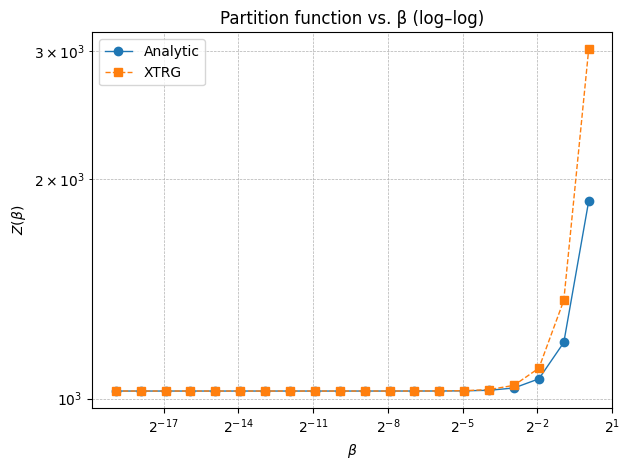

In [203]:
J = 1.0   
L = 10           

k_vals = np.arange(1, L + 1)                        # shape (L,)
eps_k = J * np.cos(k_vals * np.pi / (L + 1))        # shape (L,)
beta_vals = 2.0 ** np.arange(1, 21) * 1e-6          # shape (20,)

Z_vals = np.prod(1.0 + np.exp(-beta_vals[:, None] * eps_k), axis=1) 

xtrg_vals = np.asarray(pflist)          

fig, ax = plt.subplots()

ax.plot(beta_vals, Z_vals, marker='o',           linewidth=1, label='Analytic')
ax.plot(beta_vals, xtrg_vals, marker='s', ls='--', linewidth=1, label='XTRG')

ax.set_xscale('log', base=2)  
ax.set_yscale('log', base=10)                    

ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$Z(\beta)$')
ax.set_title('Partition function vs. β (log–log)')
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.savefig('xtrg.pdf')
plt.show()

In [204]:
b4=np.load('4.svz.npz')
b8=np.load('8.svz.npz')
b10=np.load('10.svz.npz')
b30=np.load('30.svz.npz')
b50=np.load('50.svz.npz')

x4=b4['arr_0']
x8=b8['arr_0']
x10=b10['arr_0']
x30=b30['arr_0']
x50=b50['arr_0']

diff4=np.abs(Z_vals-x4)
diff8=np.abs(Z_vals-x8)
diff10=np.abs(Z_vals-x10)
diff30=np.abs(Z_vals-x30)
diff50=np.abs(Z_vals-x50)




In [202]:
def free(partition_vals, beta_list):
   
    partition_vals = np.asarray(partition_vals, dtype=float)
    beta_list      = np.asarray(beta_list,      dtype=float)

    if partition_vals.shape != beta_list.shape:
        raise ValueError("partition_vals and beta_list must have the same shape")

    return -np.log2(partition_vals) / beta_list

In [205]:
f4=free(x4, beta_vals)
f8=free(x8, beta_vals)
f10=free(x10, beta_vals)
f30=free(x30, beta_vals)
f50=free(x50, beta_vals)

/var/folders/_h/79lspp25583bxfn_0hjyr5fc0000gn/T/ipykernel_94391/2706011622.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  partition_vals = np.asarray(partition_vals, dtype=float)


In [206]:
acc=free(Z_vals, beta_vals)
fdif4=np.abs(acc-f4)
fdif8=np.abs(acc-f8)
fdif10=np.abs(acc-f10)
fdif30=np.abs(acc-f30)
fdif50=np.abs(acc-f50)


In [207]:
relerror4=[np.abs(m/n) for m,n in zip(fdif4,acc)]
relerror8=[np.abs(m/n) for m,n in zip(fdif8,acc)]
relerror10=[np.abs(m/n) for m,n in zip(fdif10,acc)]
relerror30=[np.abs(m/n) for m,n in zip(fdif30,acc)]
relerror50=[np.abs(m/n) for m,n in zip(fdif50,acc)]


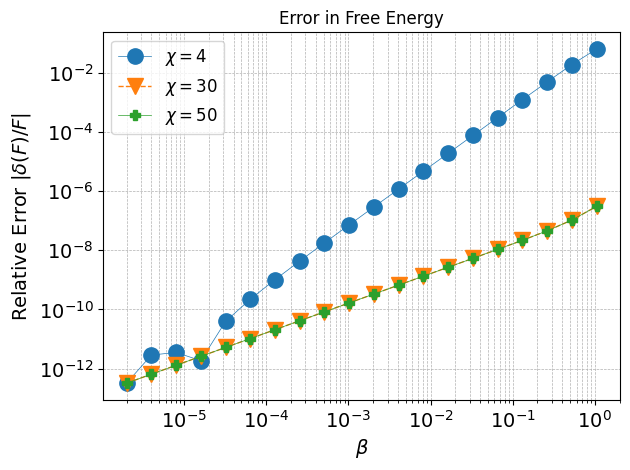

In [224]:
x = 2.0 ** np.arange(1, 21) * 1e-6

plt.figure()

plt.plot(x, relerror4, marker='o', linestyle='-', label='$\chi=4$',markersize=11, linewidth=0.5)
plt.plot(x, relerror30, marker='v', linestyle='--', label='$\chi=30$',markersize=12, linewidth=1)
plt.plot(x, relerror50, marker='P', linestyle='-', label='$\chi=50$', markersize=7, linewidth=0.5)

plt.yscale('log')
plt.xscale('log')

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12)  


plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'Relative Error $|\delta(F)/F|$', fontsize=14)
plt.title('Error in Free Energy')
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('error.pdf')

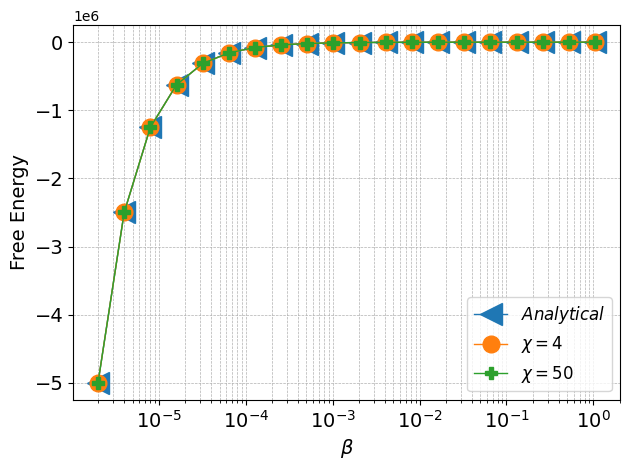

In [225]:
x = 2.0 ** np.arange(1, 21) * 1e-6

plt.figure()
plt.plot(x, acc, marker='<', linestyle='-', label='$Analytical$', markersize=16, linewidth=1)
plt.plot(x, f4, marker='o', linestyle='-', label='$\chi=4$', markersize=12, linewidth=1)
plt.plot(x, f50, marker='P', linestyle='-', label='$\chi=50$', markersize=8, linewidth=1)

plt.xscale('log')

plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'Free Energy', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12)  

plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('f.pdf')

In [189]:
acc

array([-5.00000000e+06, -2.50000000e+06, -1.25000000e+06, -6.25000000e+05,
       -3.12500000e+05, -1.56250000e+05, -7.81250001e+04, -3.90625002e+04,
       -1.95312504e+04, -9.76562583e+03, -4.88281416e+03, -2.44140957e+03,
       -1.22070977e+03, -6.10364858e+02, -3.05202372e+02, -1.52641068e+02,
       -7.64002595e+01, -3.83592852e+01, -1.94956179e+01, -1.03620561e+01])

In [211]:
2**(20)*10**(-6)

1.048576